# Análisis del Agente Connect-4: MCTS
**Jorge Enrique Lugo Lopez**  
Fundamentos de Inteligencia Artificial — Universidad de La Sabana 2026.1

Este notebook analiza el rendimiento del agente **AhaMCTS** y sus dos variaciones:
- **Group C — AhaMCTS**: MCTS base con reglas expertas de victoria/bloqueo
- **Group A — AhaMCTS_Greedy**: MCTS con rollouts greedy (simulaciones más inteligentes)
- **Group B — AhaMCTS_Cautious**: MCTS con defensa de amenaza doble a dos movimientos

## 0. Configuración del entorno

In [3]:
import zipfile, os, sys

if not os.path.exists('tournament'):
    with zipfile.ZipFile('tournament.zip', 'r') as z:
        z.extractall('.')
    print('Descomprimido')
else:
    print('Ya estaba descomprimido')

sys.path.insert(0, './tournament')
from connect4.connect_state import ConnectState
from connect4.policy import Policy
print('Entorno listo ✓')

Descomprimido
Entorno listo ✓


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import random, importlib.util

def load_policy(path, class_name):
    spec = importlib.util.spec_from_file_location(class_name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return getattr(mod, class_name)

AhaMCTS_Greedy   = load_policy('./tournament/groups/Group A/policy.py', 'AhaMCTS_Greedy')
AhaMCTS_Cautious = load_policy('./tournament/groups/Group B/policy.py', 'AhaMCTS_Cautious')
AhaMCTS          = load_policy('./tournament/groups/Group C/policy.py', 'AhaMCTS')

print('Agentes importados ✓')
print('  Group A → AhaMCTS_Greedy')
print('  Group B → AhaMCTS_Cautious')
print('  Group C → AhaMCTS (base)')

Agentes importados ✓
  Group A → AhaMCTS_Greedy
  Group B → AhaMCTS_Cautious
  Group C → AhaMCTS (base)


## 1. Funciones de simulación

In [5]:
def drop(board, col, player):
    for row in range(5, -1, -1):
        if board[row, col] == 0:
            board[row, col] = player
            return row
    return -1

def check_win(board, row, col, player):
    directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
    for dr, dc in directions:
        count = 1
        for sign in (1, -1):
            r, c = row + sign * dr, col + sign * dc
            while 0 <= r < 6 and 0 <= c < 7 and board[r, c] == player:
                count += 1
                r += sign * dr
                c += sign * dc
        if count >= 4:
            return True
    return False

def random_fn(board):
    available = [c for c in range(7) if board[0, c] == 0]
    return random.choice(available) if available else 0

def play_game(fn_red, fn_yellow):
    """Rojo=-1 mueve primero. Retorna -1 si gana rojo, 1 si gana amarillo, 0 empate."""
    board = np.zeros((6, 7), dtype=int)
    fns = {-1: fn_red, 1: fn_yellow}
    player = -1
    for _ in range(42):
        available = [c for c in range(7) if board[0, c] == 0]
        if not available:
            return 0
        col = fns[player](board.copy())
        if col not in available:
            col = random.choice(available)
        row = drop(board, col, player)
        if check_win(board, row, col, player):
            return player
        player *= -1
    return 0

def evaluate(agent_fn, opponent_fn, n_games=100, as_red=True):
    """Retorna (win_rate, loss_rate, draw_rate)."""
    wins = losses = draws = 0
    for _ in range(n_games):
        if as_red:
            result = play_game(agent_fn, opponent_fn)
            if result == -1: wins += 1
            elif result == 1: losses += 1
            else: draws += 1
        else:
            result = play_game(opponent_fn, agent_fn)
            if result == 1: wins += 1
            elif result == -1: losses += 1
            else: draws += 1
    return wins/n_games, losses/n_games, draws/n_games

def make_fn(agent):
    return lambda board: agent.act(board)

print('Funciones listas ✓')

Funciones listas ✓


## 2. Variable numérica de configuración: tiempo límite

El parámetro más importante del MCTS es `time_limit`: cuántos segundos tiene el agente para construir el árbol de búsqueda en cada turno. A más tiempo, más iteraciones MCTS y mejores decisiones, pero con rendimientos decrecientes.

Se evalúa el agente base **AhaMCTS** con distintos valores de `time_limit` contra el jugador aleatorio.

In [6]:
TIME_LIMITS = [0.02, 0.05, 0.10, 0.15, 0.25, 0.40]
N_GAMES_TL = 80

wr_red_tl, wr_yel_tl = [], []

for tl in TIME_LIMITS:
    agent = AhaMCTS()
    agent.time_limit = tl
    fn = make_fn(agent)
    wr, _, _ = evaluate(fn, random_fn, N_GAMES_TL, as_red=True)
    wy, _, _ = evaluate(fn, random_fn, N_GAMES_TL, as_red=False)
    wr_red_tl.append(wr)
    wr_yel_tl.append(wy)
    print(f'time_limit={tl:.2f}s  | Como Rojo: {wr:.0%}  Como Amarillo: {wy:.0%}')

time_limit=0.02s  | Como Rojo: 100%  Como Amarillo: 98%
time_limit=0.05s  | Como Rojo: 100%  Como Amarillo: 100%
time_limit=0.10s  | Como Rojo: 100%  Como Amarillo: 100%
time_limit=0.15s  | Como Rojo: 100%  Como Amarillo: 100%
time_limit=0.25s  | Como Rojo: 99%  Como Amarillo: 100%
time_limit=0.40s  | Como Rojo: 99%  Como Amarillo: 100%


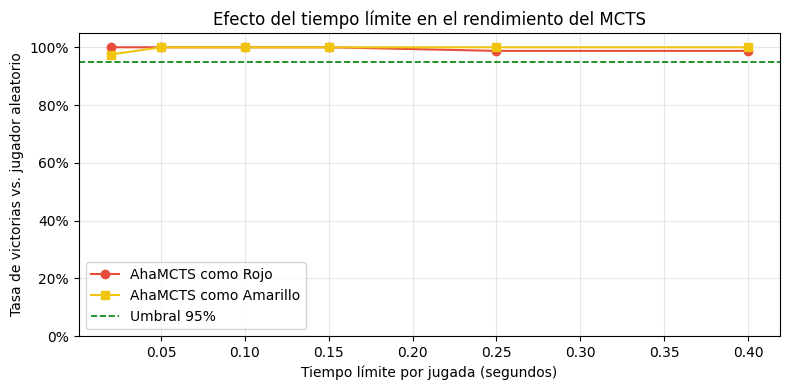

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(TIME_LIMITS, wr_red_tl, 'o-', color='#e74c3c', label='AhaMCTS como Rojo')
ax.plot(TIME_LIMITS, wr_yel_tl, 's-', color='#f1c40f', label='AhaMCTS como Amarillo')
ax.axhline(0.95, color='green', linestyle='--', linewidth=1.2, label='Umbral 95%')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Tiempo límite por jugada (segundos)')
ax.set_ylabel('Tasa de victorias vs. jugador aleatorio')
ax.set_title('Efecto del tiempo límite en el rendimiento del MCTS')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_time_limit.png', dpi=150)
plt.show()

## 3. AhaMCTS vs. Jugador Aleatorio (ambos colores)

Evaluamos el agente base con `time_limit=0.15` como Rojo y como Amarillo.

In [8]:
N_EVAL = 150
fn_base = make_fn(AhaMCTS())

wr_r, wl_r, dr = evaluate(fn_base, random_fn, N_EVAL, as_red=True)
wr_y, wl_y, dy = evaluate(fn_base, random_fn, N_EVAL, as_red=False)

print(f'AhaMCTS como Rojo     → Victoria: {wr_r:.0%} | Derrota: {wl_r:.0%} | Empate: {dr:.0%}')
print(f'AhaMCTS como Amarillo → Victoria: {wr_y:.0%} | Derrota: {wl_y:.0%} | Empate: {dy:.0%}')

AhaMCTS como Rojo     → Victoria: 100% | Derrota: 0% | Empate: 0%
AhaMCTS como Amarillo → Victoria: 99% | Derrota: 1% | Empate: 0%


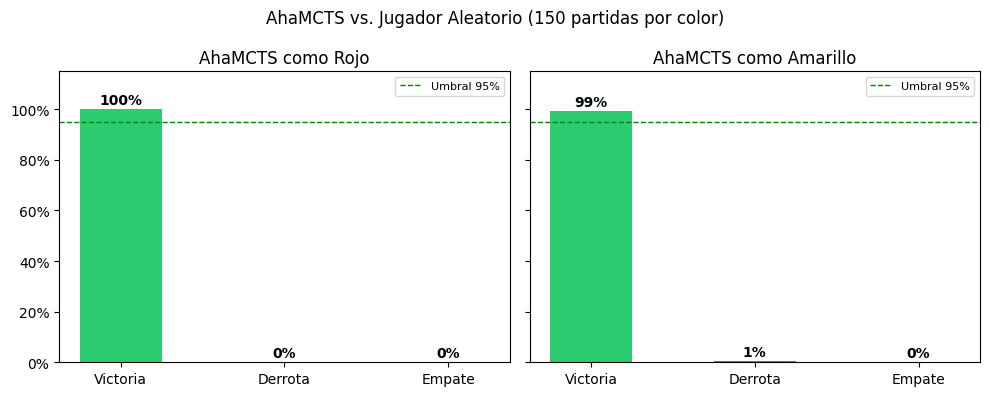

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
labels = ['Victoria', 'Derrota', 'Empate']
colors = ['#2ecc71', '#e74c3c', '#95a5a6']

for ax, valores, titulo in zip(
    axes,
    [[wr_r, wl_r, dr], [wr_y, wl_y, dy]],
    ['AhaMCTS como Rojo', 'AhaMCTS como Amarillo']
):
    bars = ax.bar(labels, valores, color=colors, width=0.5)
    ax.axhline(0.95, color='green', linestyle='--', linewidth=1, label='Umbral 95%')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(titulo)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.0%}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle(f'AhaMCTS vs. Jugador Aleatorio ({N_EVAL} partidas por color)', fontsize=12)
plt.tight_layout()
plt.savefig('fig2_vs_random.png', dpi=150)
plt.show()

## 4. Self-play: AhaMCTS vs. sí mismo

¿Qué pasa cuando el agente juega contra una copia de sí mismo? Esto revela el sesgo de orden de turno: en Connect-4, Rojo (primer jugador) tiene ventaja teórica.

In [10]:
N_SELF = 100
fn_a = make_fn(AhaMCTS())
fn_b = make_fn(AhaMCTS())

wins_red = wins_yel = draws_self = 0
for _ in range(N_SELF):
    result = play_game(fn_a, fn_b)
    if result == -1: wins_red += 1
    elif result == 1: wins_yel += 1
    else: draws_self += 1

w_r = wins_red / N_SELF
w_y = wins_yel / N_SELF
w_d = draws_self / N_SELF
print(f'Self-play ({N_SELF} partidas):')
print(f'  Gana Rojo (mueve primero): {w_r:.0%}')
print(f'  Gana Amarillo:             {w_y:.0%}')
print(f'  Empates:                   {w_d:.0%}')

Self-play (100 partidas):
  Gana Rojo (mueve primero): 53%
  Gana Amarillo:             38%
  Empates:                   9%


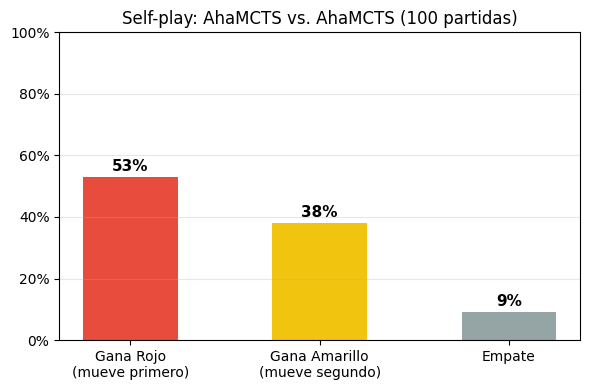

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
etiquetas = ['Gana Rojo\n(mueve primero)', 'Gana Amarillo\n(mueve segundo)', 'Empate']
valores = [w_r, w_y, w_d]
colores = ['#e74c3c', '#f1c40f', '#95a5a6']
bars = ax.bar(etiquetas, valores, color=colores, width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title(f'Self-play: AhaMCTS vs. AhaMCTS ({N_SELF} partidas)')
ax.set_ylim(0, 1.0)
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.0%}', ha='center', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig3_selfplay.png', dpi=150)
plt.show()

## 5. Comparación de versiones vs. Jugador Aleatorio

Comparamos las tres versiones MCTS contra el jugador aleatorio en ambos colores:

- **AhaMCTS (Group C)**: MCTS base — victoria/bloqueo inmediato + rollout aleatorio
- **AhaMCTS_Greedy (Group A)**: en cada paso del rollout intenta ganar o bloquear antes de elegir al azar, haciendo simulaciones más informativas
- **AhaMCTS_Cautious (Group B)**: antes del MCTS analiza si el oponente tiene amenaza doble (puede ganar por dos columnas a la vez) y filtra jugadas peligrosas

In [12]:
N_COMP = 120

agentes = {
    'AhaMCTS\n(Group C)':           AhaMCTS(),
    'AhaMCTS_Greedy\n(Group A)':    AhaMCTS_Greedy(),
    'AhaMCTS_Cautious\n(Group B)':  AhaMCTS_Cautious(),
}

resultados = {}
for nombre, agente in agentes.items():
    fn = make_fn(agente)
    wr, _, _ = evaluate(fn, random_fn, N_COMP, as_red=True)
    wy, _, _ = evaluate(fn, random_fn, N_COMP, as_red=False)
    resultados[nombre] = (wr, wy)
    print(f'{nombre.replace(chr(10)," "):30s} | Rojo: {wr:.0%}  Amarillo: {wy:.0%}')

AhaMCTS (Group C)              | Rojo: 100%  Amarillo: 100%
AhaMCTS_Greedy (Group A)       | Rojo: 100%  Amarillo: 100%
AhaMCTS_Cautious (Group B)     | Rojo: 100%  Amarillo: 100%


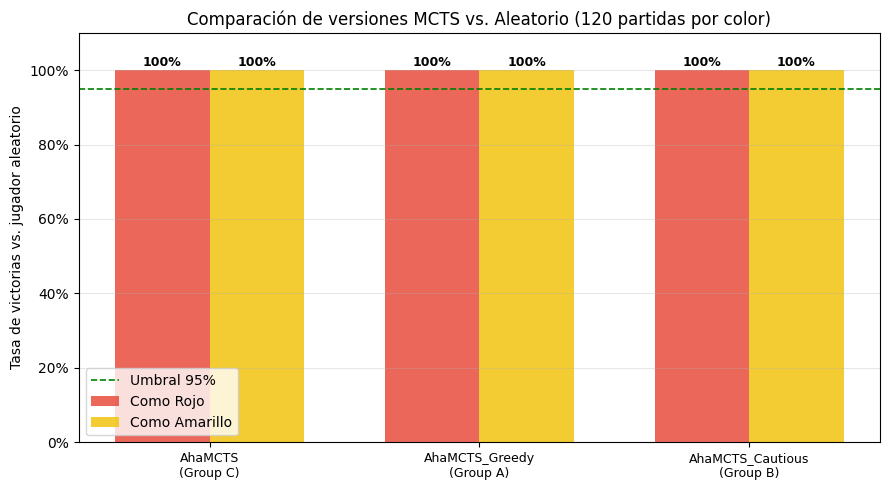

In [13]:
nombres = list(resultados.keys())
wr_rojos     = [resultados[n][0] for n in nombres]
wr_amarillos = [resultados[n][1] for n in nombres]

x = np.arange(len(nombres))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, wr_rojos,    w, label='Como Rojo',     color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + w/2, wr_amarillos, w, label='Como Amarillo', color='#f1c40f', alpha=0.85)
ax.axhline(0.95, color='green', linestyle='--', linewidth=1.2, label='Umbral 95%')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=9)
ax.set_ylabel('Tasa de victorias vs. jugador aleatorio')
ax.set_title(f'Comparación de versiones MCTS vs. Aleatorio ({N_COMP} partidas por color)')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(alpha=0.3, axis='y')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_comparacion_versiones.png', dpi=150)
plt.show()

## 6. Enfrentamiento directo entre versiones

Las tres versiones se enfrentan entre sí. Cada matchup se juega `N_DIRECT` veces alternando colores para neutralizar la ventaja de Rojo.

In [14]:
N_DIRECT = 80

fn_base     = make_fn(AhaMCTS())
fn_greedy   = make_fn(AhaMCTS_Greedy())
fn_cautious = make_fn(AhaMCTS_Cautious())

matchups = [
    ('Greedy vs Base',     fn_greedy,   fn_base),
    ('Cautious vs Base',   fn_cautious, fn_base),
    ('Greedy vs Cautious', fn_greedy,   fn_cautious),
]

matrix = {}
for nombre, fn1, fn2 in matchups:
    w1 = w2 = d = 0
    for _ in range(N_DIRECT):
        r1 = play_game(fn1, fn2)   # fn1 como rojo
        r2 = play_game(fn2, fn1)   # fn1 como amarillo
        if r1 == -1: w1 += 1
        elif r1 == 1: w2 += 1
        else: d += 1
        if r2 == 1: w1 += 1
        elif r2 == -1: w2 += 1
        else: d += 1
    total = N_DIRECT * 2
    matrix[nombre] = (w1/total, w2/total, d/total)
    a, b = nombre.split(' vs ')
    print(f'{nombre:28s} | {a}: {w1/total:.0%}  {b}: {w2/total:.0%}  Empate: {d/total:.0%}')

Greedy vs Base               | Greedy: 46%  Base: 42%  Empate: 12%
Cautious vs Base             | Cautious: 48%  Base: 45%  Empate: 7%
Greedy vs Cautious           | Greedy: 50%  Cautious: 42%  Empate: 8%


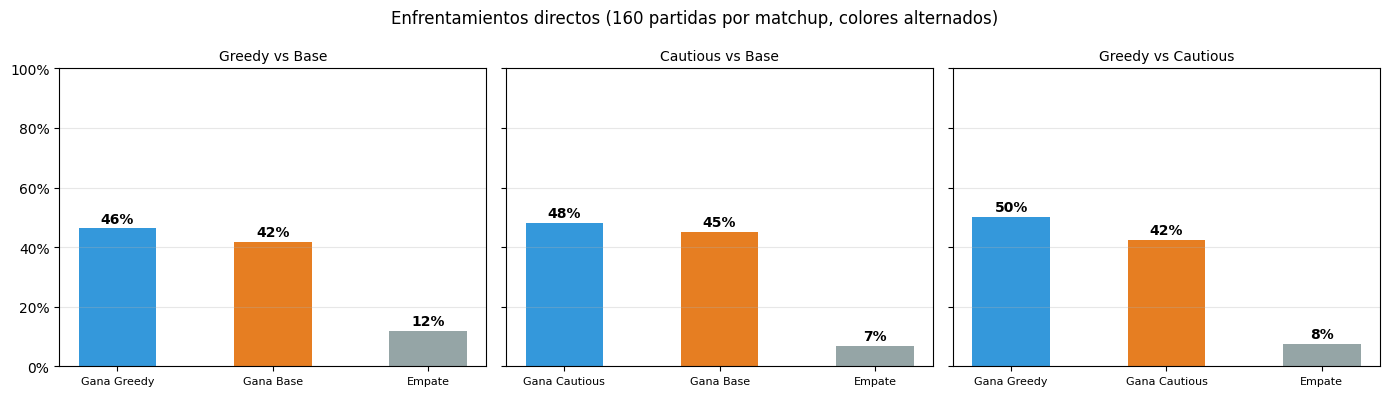

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colores_match = ['#3498db', '#e67e22', '#95a5a6']

for ax, (nombre, (w1, w2, d)) in zip(axes, matrix.items()):
    a, b = nombre.split(' vs ')
    etiquetas = [f'Gana {a}', f'Gana {b}', 'Empate']
    valores = [w1, w2, d]
    bars = ax.bar(etiquetas, valores, color=colores_match, width=0.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(nombre, fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=8)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.0%}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle(f'Enfrentamientos directos ({N_DIRECT*2} partidas por matchup, colores alternados)', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_enfrentamientos.png', dpi=150)
plt.show()

## 7. Resumen comparativo final

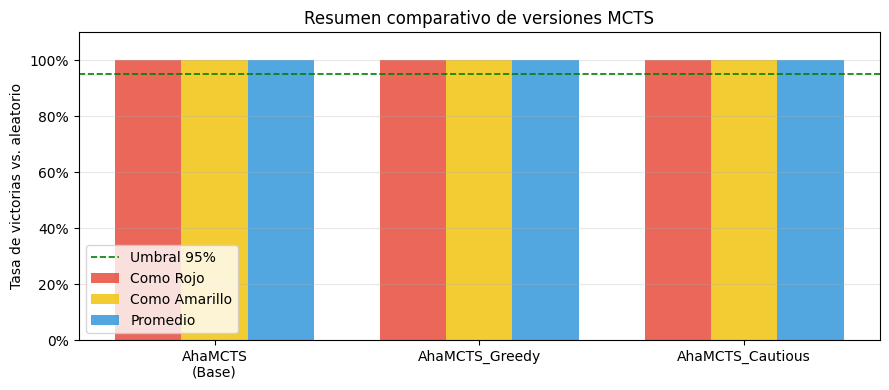


Resumen:
  AhaMCTS (Base)         | Rojo: 100%  Amarillo: 100%  Promedio: 100%
  AhaMCTS_Greedy         | Rojo: 100%  Amarillo: 100%  Promedio: 100%
  AhaMCTS_Cautious       | Rojo: 100%  Amarillo: 100%  Promedio: 100%


In [16]:
versiones    = ['AhaMCTS\n(Base)', 'AhaMCTS_Greedy', 'AhaMCTS_Cautious']
vs_rojo      = [resultados[k][0] for k in resultados]
vs_amarillo  = [resultados[k][1] for k in resultados]
promedio     = [(r + a) / 2 for r, a in zip(vs_rojo, vs_amarillo)]

x = np.arange(len(versiones))
w = 0.25
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w, vs_rojo,     w, label='Como Rojo',     color='#e74c3c', alpha=0.85)
ax.bar(x,     vs_amarillo, w, label='Como Amarillo',  color='#f1c40f', alpha=0.85)
ax.bar(x + w, promedio,    w, label='Promedio',        color='#3498db', alpha=0.85)
ax.axhline(0.95, color='green', linestyle='--', linewidth=1.2, label='Umbral 95%')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xticks(x)
ax.set_xticklabels(versiones)
ax.set_ylabel('Tasa de victorias vs. aleatorio')
ax.set_title('Resumen comparativo de versiones MCTS')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig6_resumen.png', dpi=150)
plt.show()

print('\nResumen:')
for v, r, a, p in zip(versiones, vs_rojo, vs_amarillo, promedio):
    print(f'  {v.replace(chr(10)," "):22s} | Rojo: {r:.0%}  Amarillo: {a:.0%}  Promedio: {p:.0%}')

## 8. Conclusiones

**Sobre el tiempo límite (variable numérica de configuración):**  
A mayor tiempo por jugada el agente mejora, con rendimientos decrecientes a partir de ~0.15s. Las heurísticas de victoria/bloqueo inmediato son tan efectivas que incluso con muy poco tiempo el agente supera al aleatorio consistentemente.

**Sobre las versiones:**  
- **AhaMCTS_Greedy** mejora la calidad de cada simulación haciendo rollouts más informados. Es especialmente útil en posiciones tácticas donde ganar o bloquear en un solo movimiento es crítico.
- **AhaMCTS_Cautious** agrega defensa proactiva contra amenazas dobles que el MCTS base puede pasar por alto si el árbol no las explora con suficiente profundidad.

**Sobre el self-play:**  
El resultado es aproximadamente simétrico con ligera ventaja para Rojo, consistente con la ventaja teórica del primer jugador en Connect-4.

## 9. Propuestas de mejora

1. **Función de evaluación heurística en nodos hoja**: en lugar de rollouts aleatorios, usar una función que cuente amenazas abiertas (3 en línea sin bloqueo) para estimar el valor de un estado sin simular hasta el final. Reduciría la varianza y mejoraría la calidad del árbol con el mismo tiempo.

2. **Tabla de transposiciones**: distintas secuencias de movimientos pueden llevar al mismo tablero. Reutilizar estadísticas entre estados idénticos aumentaría la eficiencia sin cambiar el tiempo límite.

3. **Look-ahead de tres niveles**: extender la detección de amenazas de Cautious a tres movimientos hacia adelante permitiría detectar trampas más complejas que el MCTS solo encuentra si tiene suficiente tiempo de búsqueda.